In [1]:
%load_ext autoreload
%autoreload 3

In [2]:
# ── Run-control flags ───────────────────────────────────────────────────────
FORCE_RERUN = False   # set True to recompute and overwrite pickles
FORCE_REFIT  = True    # set True to refit spikes (ignores existing spike fit pickle)

In [3]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina' # high res plotting

import sys
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/spikeparam')
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/shared_helper_modules'))

# General imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings
import pickle

warnings.filterwarnings(
    "ignore",
    message="use_inf_as_na option is deprecated",
    category=FutureWarning,
    module="seaborn")

warnings.filterwarnings(
    "ignore",
    message=r"invalid value encountered in log10",
    category=RuntimeWarning,
    module=r".*specparam.*",
)


# NeuroDSP and FOOOF modules
from neurodsp import spectral

from specparam import Bands


# Custom modules

from spk_feat_cluster_analysis import *

from spe1_plotting import *
from spikeparam.patch.fit import Spike

from config import NPX_CHANNELS, CELL_IDS, DICT_PATCH_FS, DICT_CHAN_PRED, DICT_SPK_THRESH, FILTER_SETTINGS, SPE1_DATA_ROOT, SPE1_PICKLE_ROOT


In [4]:
cell_num = 39 #MODIFY THIS WHEN RUNNING DIFFERENT CELLS 

npx_fs = 30000 # sampling rate
lfp_fs = 3500 # sampling rate

patch_fs = DICT_PATCH_FS[cell_num ]
spk_thresh = DICT_SPK_THRESH[cell_num]

npx_channels = NPX_CHANNELS
npx_patch_channel = DICT_CHAN_PRED[cell_num ]



In [5]:
# Parameters
FORCE_CLUSTER = True


### Loading spe-1 data:

I moved the data loading steps to a separate Jupyter Notebook (spe-1_load_data)




## Cell   
### Analyze Gamma LFP and whole patch clamp AP relationship for cell 

## Step 0: Get loaded data - NO LFP DATA FOR C39

In [6]:
lfp_dir = os.path.join(SPE1_DATA_ROOT, 'filt_lfp_recordings', f'c{cell_num}_lfp.npy')
patch_dir = os.path.join(SPE1_DATA_ROOT, 'filt_patch_recordings', f'c{cell_num}_patch.npy')


In [7]:


#get patch data 
patch_filt = np.load(patch_dir)
patch_one_ms = float(patch_fs  / 1000)
patch_times = np.arange(0, np.shape(patch_filt )[0]) / patch_one_ms # in ms instead of sec

## STEP 1: Detect and fit spikes from patch data

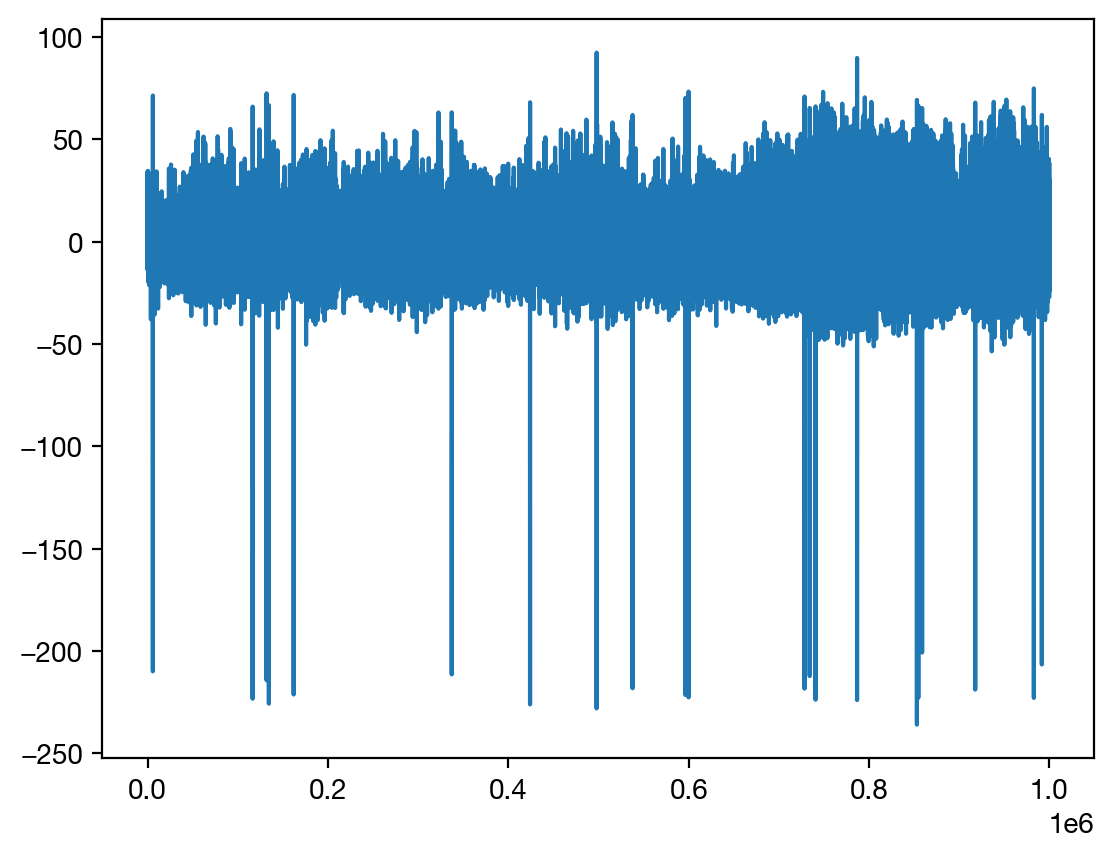

In [8]:
plt.plot(patch_filt[:1000000] )

In [9]:
spike_fit_pickle = os.path.join(SPE1_PICKLE_ROOT, 'spike_fit_pickles', f'c{cell_num}_spike_fit.pkl')
os.makedirs(os.path.dirname(spike_fit_pickle), exist_ok=True)

if not FORCE_REFIT and os.path.exists(spike_fit_pickle):
    print(f'[cache] Loading spike fit from {os.path.basename(spike_fit_pickle)}')
    with open(spike_fit_pickle, 'rb') as _fh:
        sp = pickle.load(_fh)
    _loaded_from_pickle = True
else:
    sp = Spike(thresh_amp=100, window_length=(5., 5.), smooth_frac=.01)
    _loaded_from_pickle = False

In [10]:
if not _loaded_from_pickle:
    #CHANGE FOR EACH CELL
    sp.fit(patch_filt, patch_fs, n_jobs=-1, progress=tqdm, flip_signal=True)

Spike:   0%|          | 0/313 [00:00<?, ?it/s]

Spike:   0%|          | 1/313 [00:02<14:54,  2.87s/it]

Spike:   7%|▋         | 21/313 [00:02<00:29,  9.79it/s]

Spike:  10%|█         | 32/313 [00:03<00:17, 15.95it/s]

Spike:  19%|█▉        | 61/313 [00:03<00:06, 38.39it/s]

...

Spike:  77%|███████▋  | 240/313 [00:04<00:00, 158.63it/s]

Spike:  82%|████████▏ | 258/313 [00:04<00:00, 162.93it/s]

Spike:  88%|████████▊ | 276/313 [00:04<00:00, 158.20it/s]

Spike:  96%|█████████▌| 300/313 [00:04<00:00, 165.78it/s]

Spike: 100%|██████████| 313/313 [00:04<00:00, 68.21it/s] 

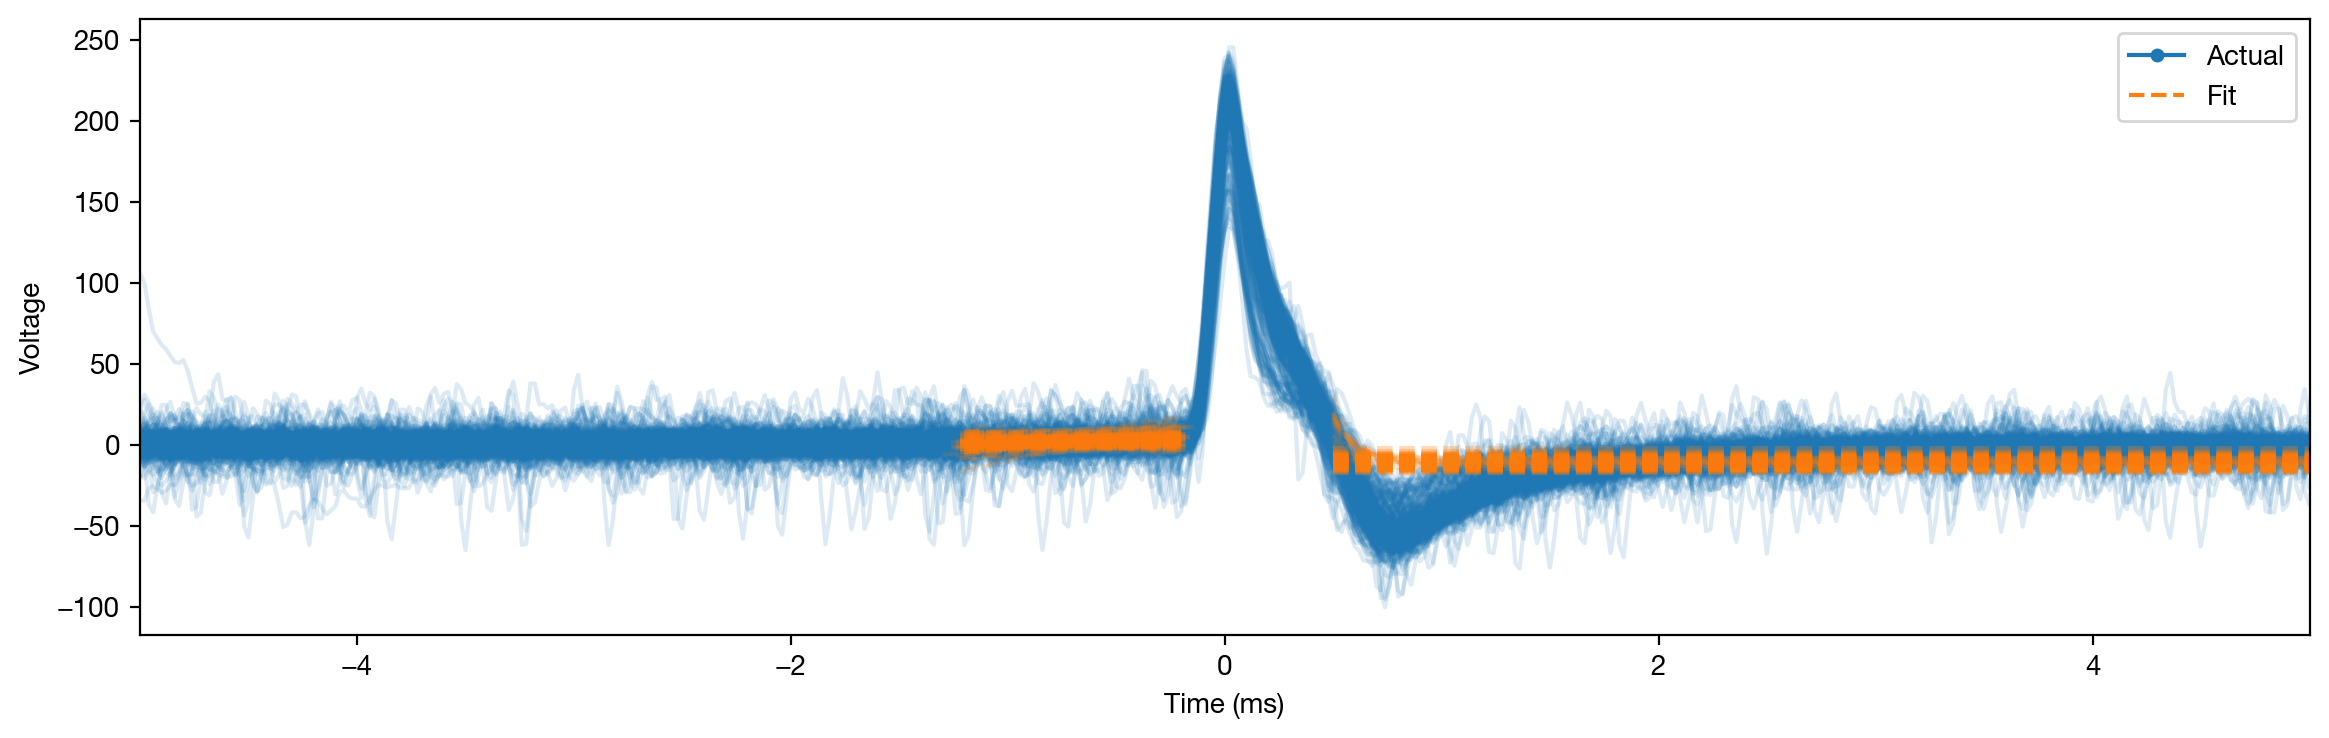

In [11]:
sp.plot()

### Filter spikes 

In [12]:
if not _loaded_from_pickle:
    sp.filter_features()
    with open(spike_fit_pickle, 'wb') as _fh:
        pickle.dump(sp, _fh)
    print(f'Saved spike fit → {os.path.basename(spike_fit_pickle)}')
else:
    print(f'[cache] {len(sp.df_features)} spikes loaded')

Saved spike fit → c39_spike_fit.pkl


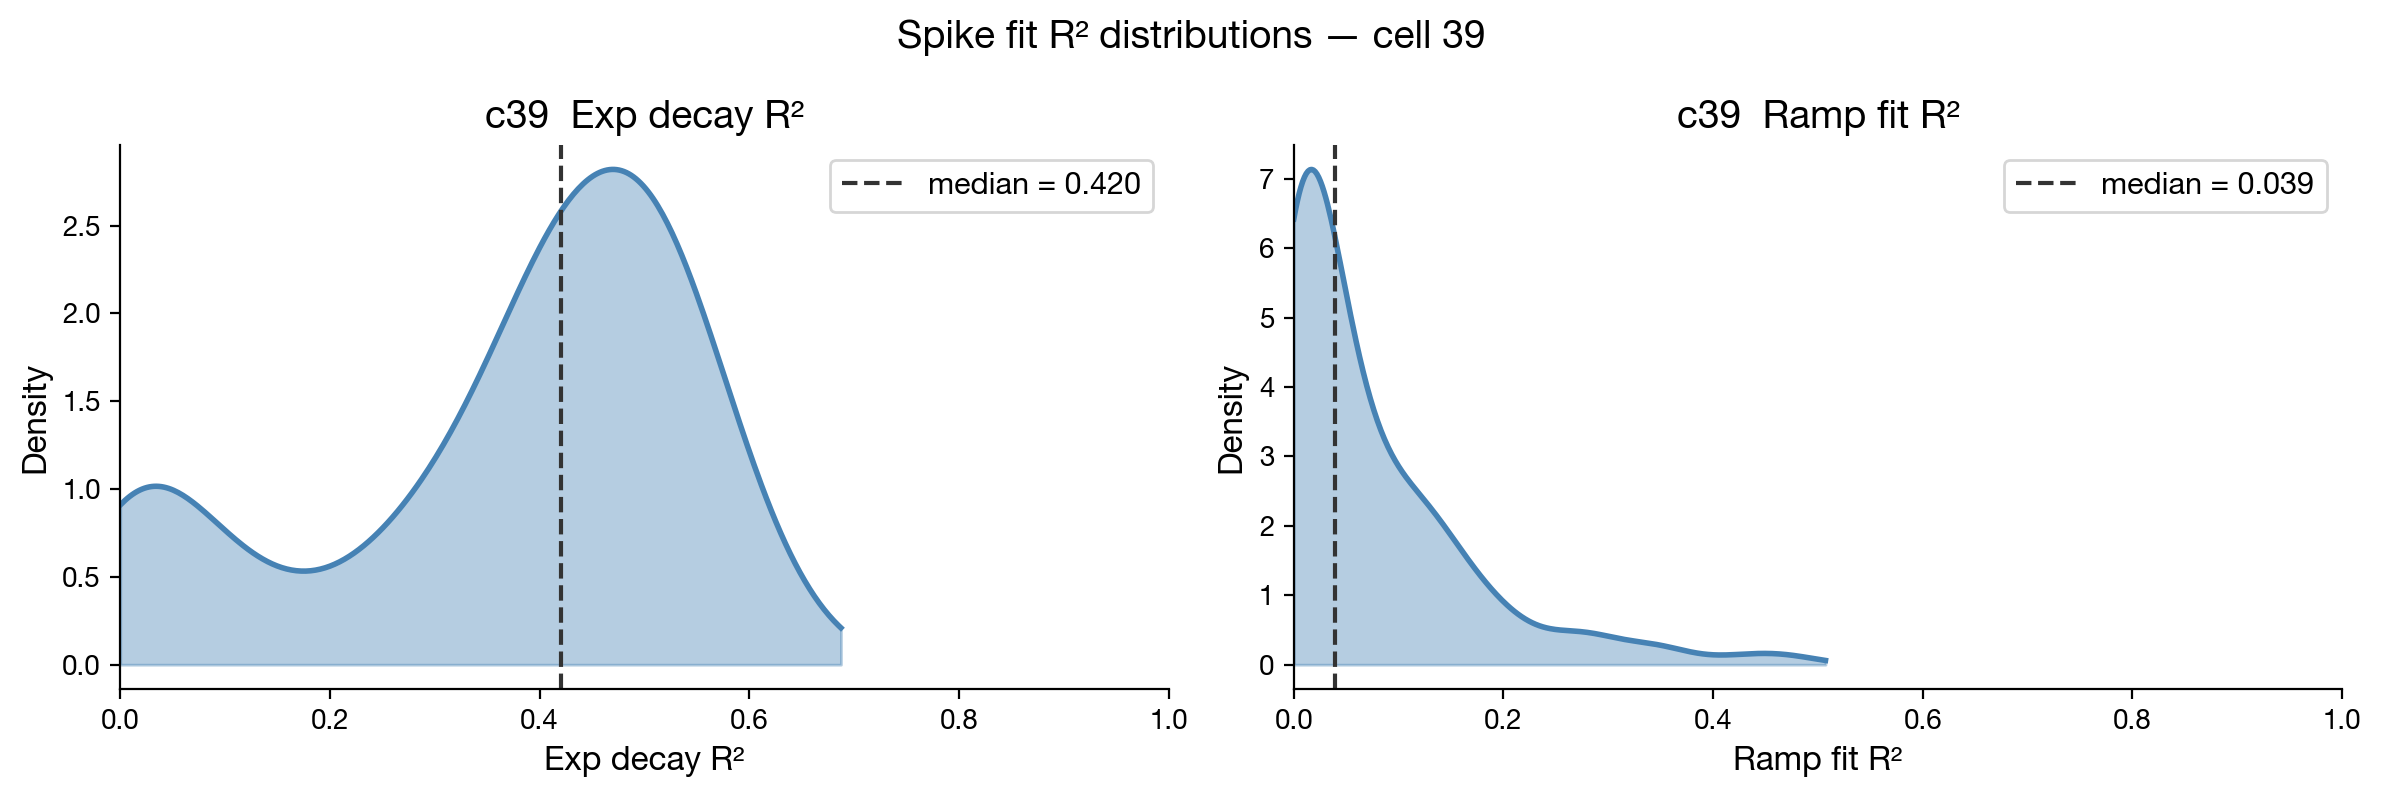

In [13]:
from scipy.stats import gaussian_kde as _kde

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, r2_arr, title in zip(
        axes,
        [sp.r_squared_exp, sp.r_squared_ramp],
        ['Exp decay R²', 'Ramp fit R²']):
    vals = np.asarray(r2_arr)
    vals = vals[np.isfinite(vals)]
    if len(vals) >= 5:
        try:
            kde_fn = _kde(vals)
            x_grid = np.linspace(max(0, vals.min() - 0.02), min(1, vals.max() + 0.02), 300)
            y_grid = kde_fn(x_grid)
            ax.fill_between(x_grid, y_grid, alpha=0.4, color='steelblue')
            ax.plot(x_grid, y_grid, color='steelblue', lw=2)
        except Exception:
            pass
    med = np.median(vals)
    ax.axvline(med, color='#333', lw=1.5, ls='--', label=f'median = {med:.3f}')
    ax.set_title(f'c{cell_num}  {title}', fontsize=14, fontweight='bold')
    ax.set_xlabel(title, fontsize=12)
    ax.set_ylabel('Density', fontsize=12)
    ax.set_xlim(0, 1)
    ax.legend(fontsize=11)
    sns.despine(ax=ax)
plt.suptitle(f'Spike fit R² distributions — cell {cell_num}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Get spike dataframe (with spike times column)

In [14]:

df_features = sp.df_features

#add columns for spike times, both in idx and ms
df_features['spk_times_idx'] = sp.spike_inds
df_features['spk_times_ms'] = patch_times[sp.spike_inds]
df_features['spk_id'] = range(len(df_features))

In [15]:
df_features

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,log_isi,spk_times_idx,spk_times_ms,spk_id
0,2.924382,0.20,3.668935,191.052817,0.20,97.340883,0.000003,-11.665409,3.344747,5884,117.623819,0
1,5.600711,0.18,7.902663,215.421038,0.20,116.247348,0.000004,-8.306219,2.489976,116527,2329.427386,1
2,2.870265,0.20,6.225112,213.184957,0.18,129.133122,0.000026,-11.045517,1.710756,131985,2638.439791,2
3,8.798707,0.20,19.503481,225.179193,0.20,129.094834,0.000009,-9.362843,2.739839,134555,2689.815253,3
4,0.363499,0.18,0.346324,211.534426,0.22,120.839963,0.000005,-11.871742,3.544520,162035,3239.152870,4
...,...,...,...,...,...,...,...,...,...,...,...,...
308,-2.896992,0.16,1.014623,132.335148,0.18,77.902316,0.000041,-7.581274,3.075887,13071985,261314.887100,308
309,-0.600317,0.18,4.999098,138.666404,0.18,79.622082,0.000004,-6.036913,1.999097,13131560,262505.818271,309
310,2.773269,0.18,6.181553,133.144504,0.20,76.896664,0.000025,-6.563757,3.362456,13136552,262605.610607,310
311,5.824142,0.18,4.451585,132.020527,0.16,90.027585,0.000038,-4.499076,3.461204,13251800,264909.470205,311


### Get spike times


In [16]:
spk_times_idx = df_features['spk_times_idx']
spk_times_ms = df_features['spk_times_ms']
spk_ids = df_features['spk_id']

In [17]:
df_features.columns

Index(['ramp_amp', 'inflection_time', 'inflection_amp', 'peak_amp',
       'peak_width', 'peak_sharpness', 'exp_lambda', 'exp_const', 'log_isi',
       'spk_times_idx', 'spk_times_ms', 'spk_id'],
      dtype='object')

## STEP 2: Cluster spike groups 

#### Plot distribution of all features

Plotting spike features...
Removing outliers using IQR method (multiplier=3)


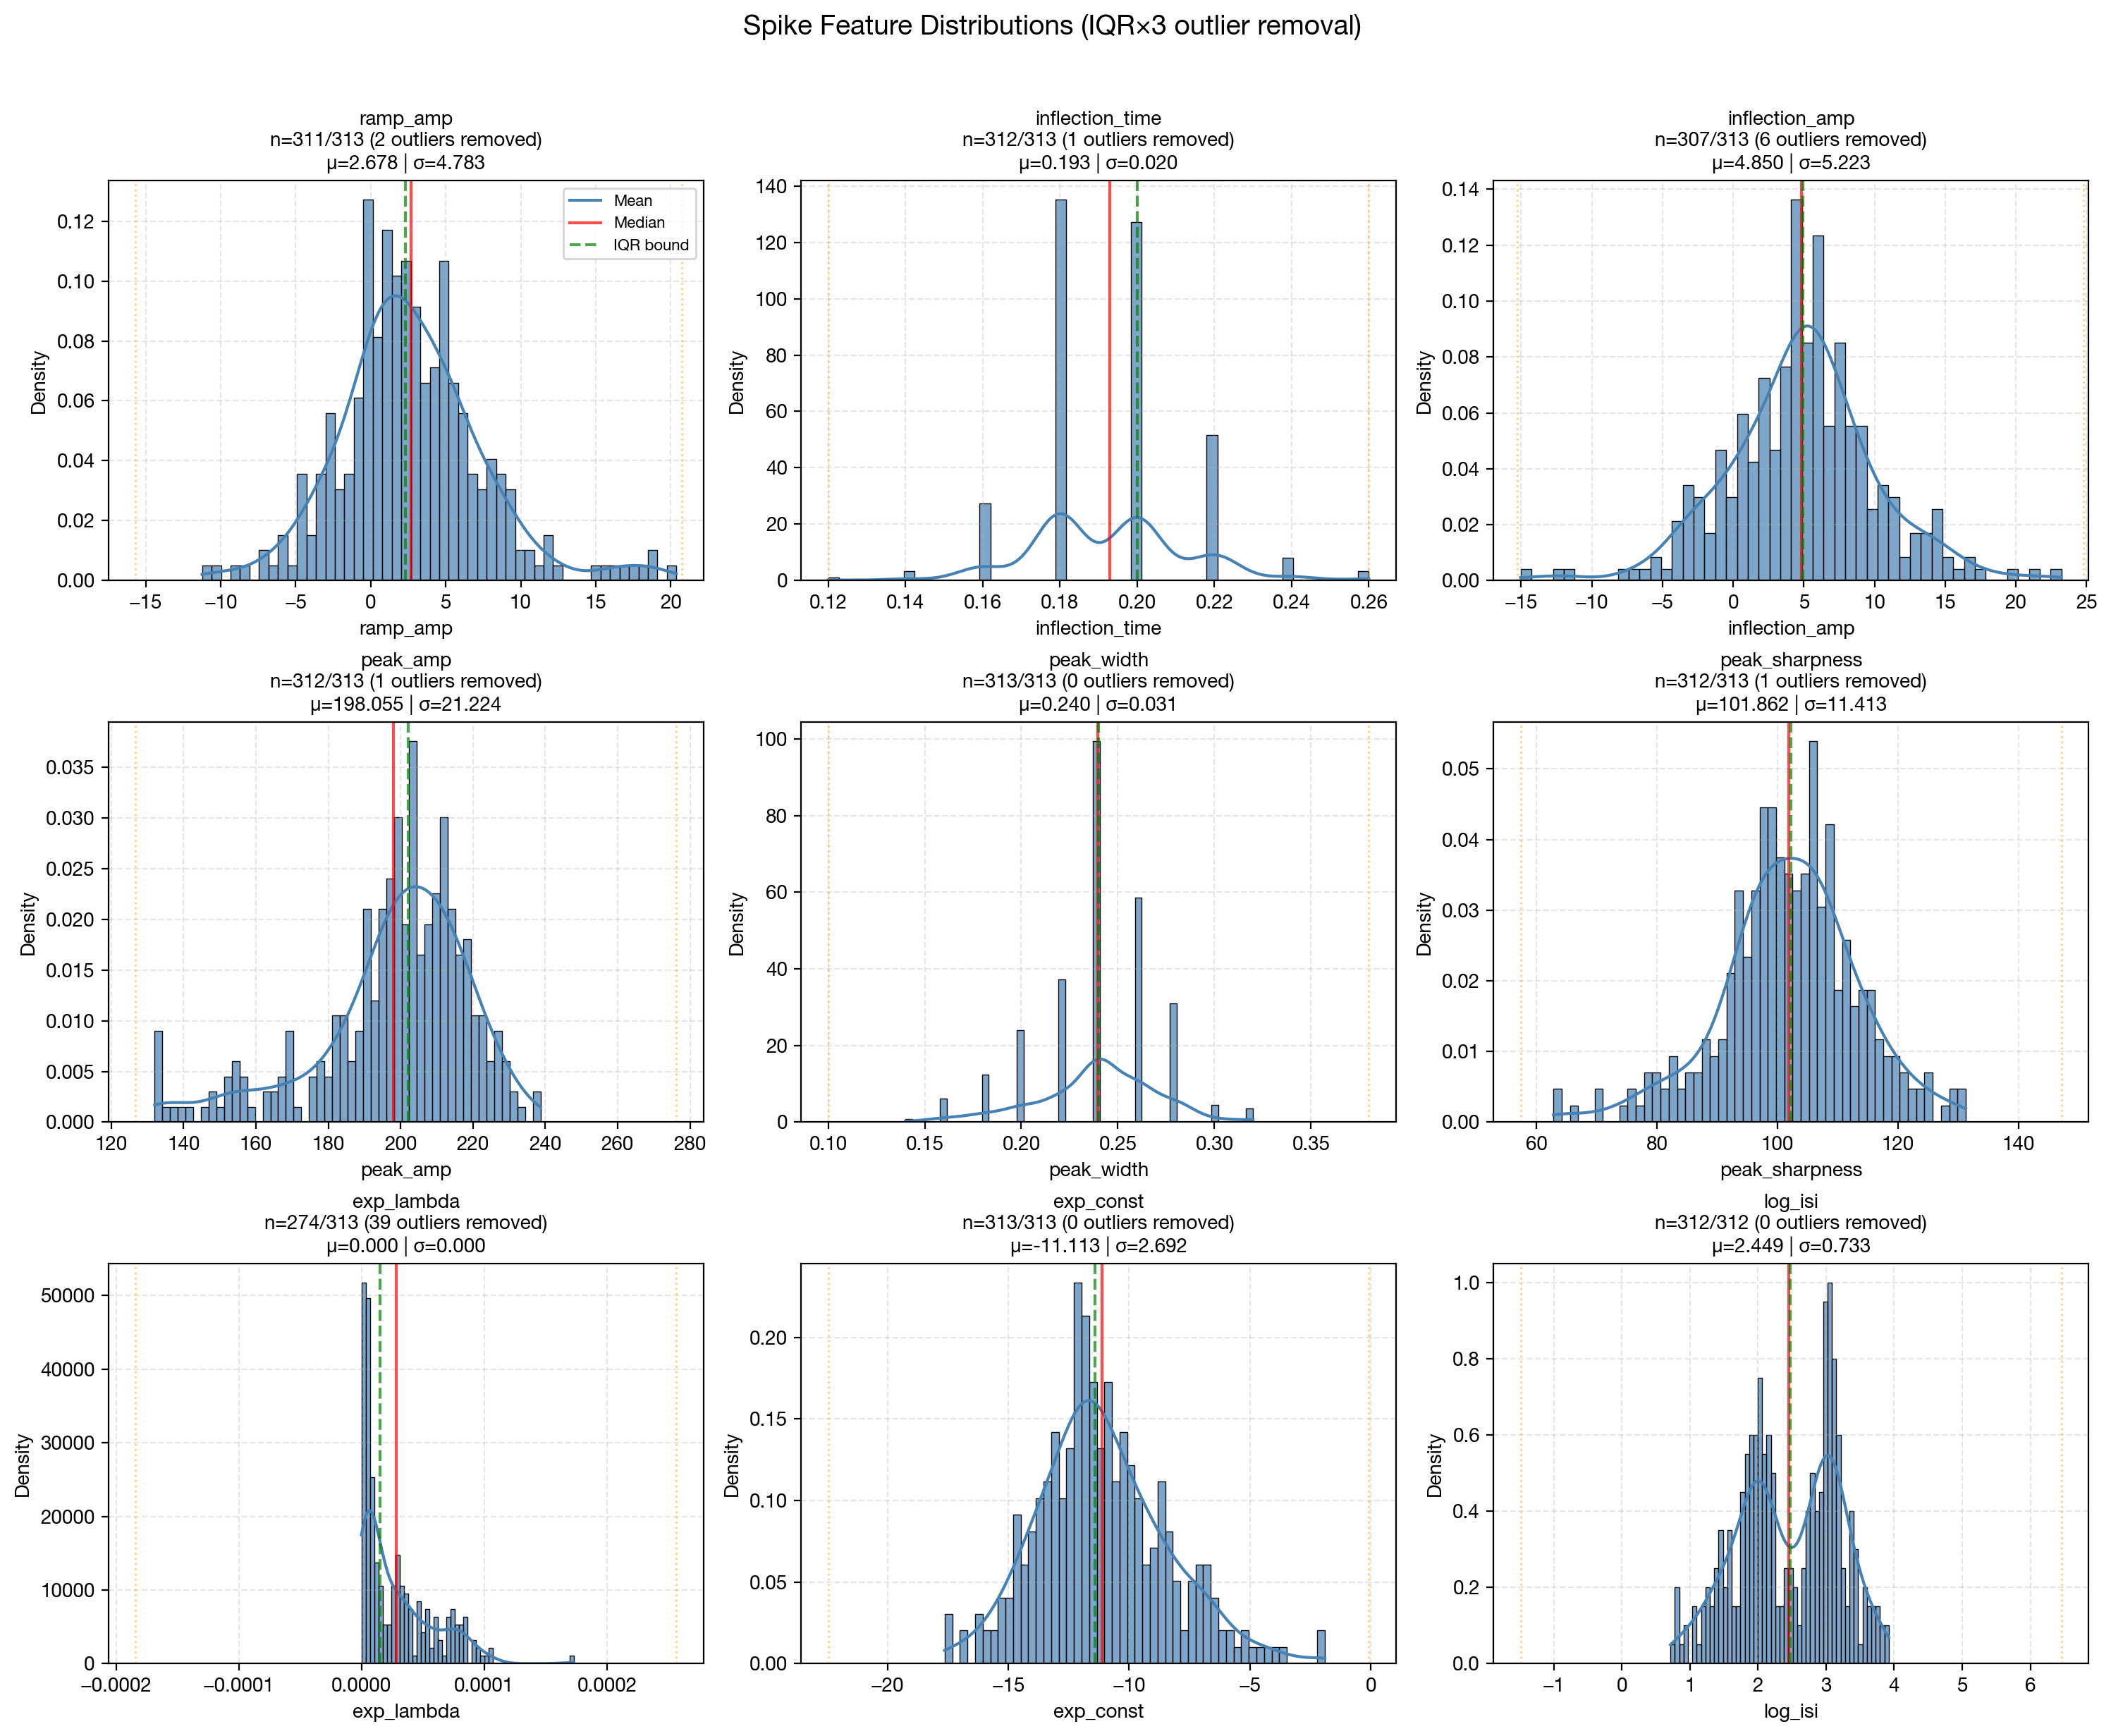


FEATURE DISTRIBUTION SUMMARY
Feature              Total N    Clean N    Outliers   % Removed  Mean       Std       
------------------------------------------------------------------------------------------
ramp_amp             313        311        2          0.6        2.678      4.783     
inflection_time      313        312        1          0.3        0.193      0.020     
inflection_amp       313        307        6          1.9        4.850      5.223     
peak_amp             313        312        1          0.3        198.055    21.224    
peak_width           313        313        0          0.0        0.240      0.031     
peak_sharpness       313        312        1          0.3        101.862    11.413    
exp_lambda           313        274        39         12.5       0.000      0.000     
exp_const            313        313        0          0.0        -11.113    2.692     
log_isi              312        312        0          0.0        2.449      0.733     


In [18]:
plot_spike_feature_distributions(df_features)

ramp_amp: Skipped - k_suggest = 1
→ inflection_time: Skipping (feature ignored).
inflection_amp: Skipped - k_suggest = 1
peak_amp: Skipped - k_suggest = 1
peak_width: Skipped - k_suggest = 1
peak_sharpness: Skipped - k_suggest = 1
exp_lambda: Skipped - k_suggest = 1
exp_const: Skipped - k_suggest = 1
log_isi: Skipped - k_suggest = 1


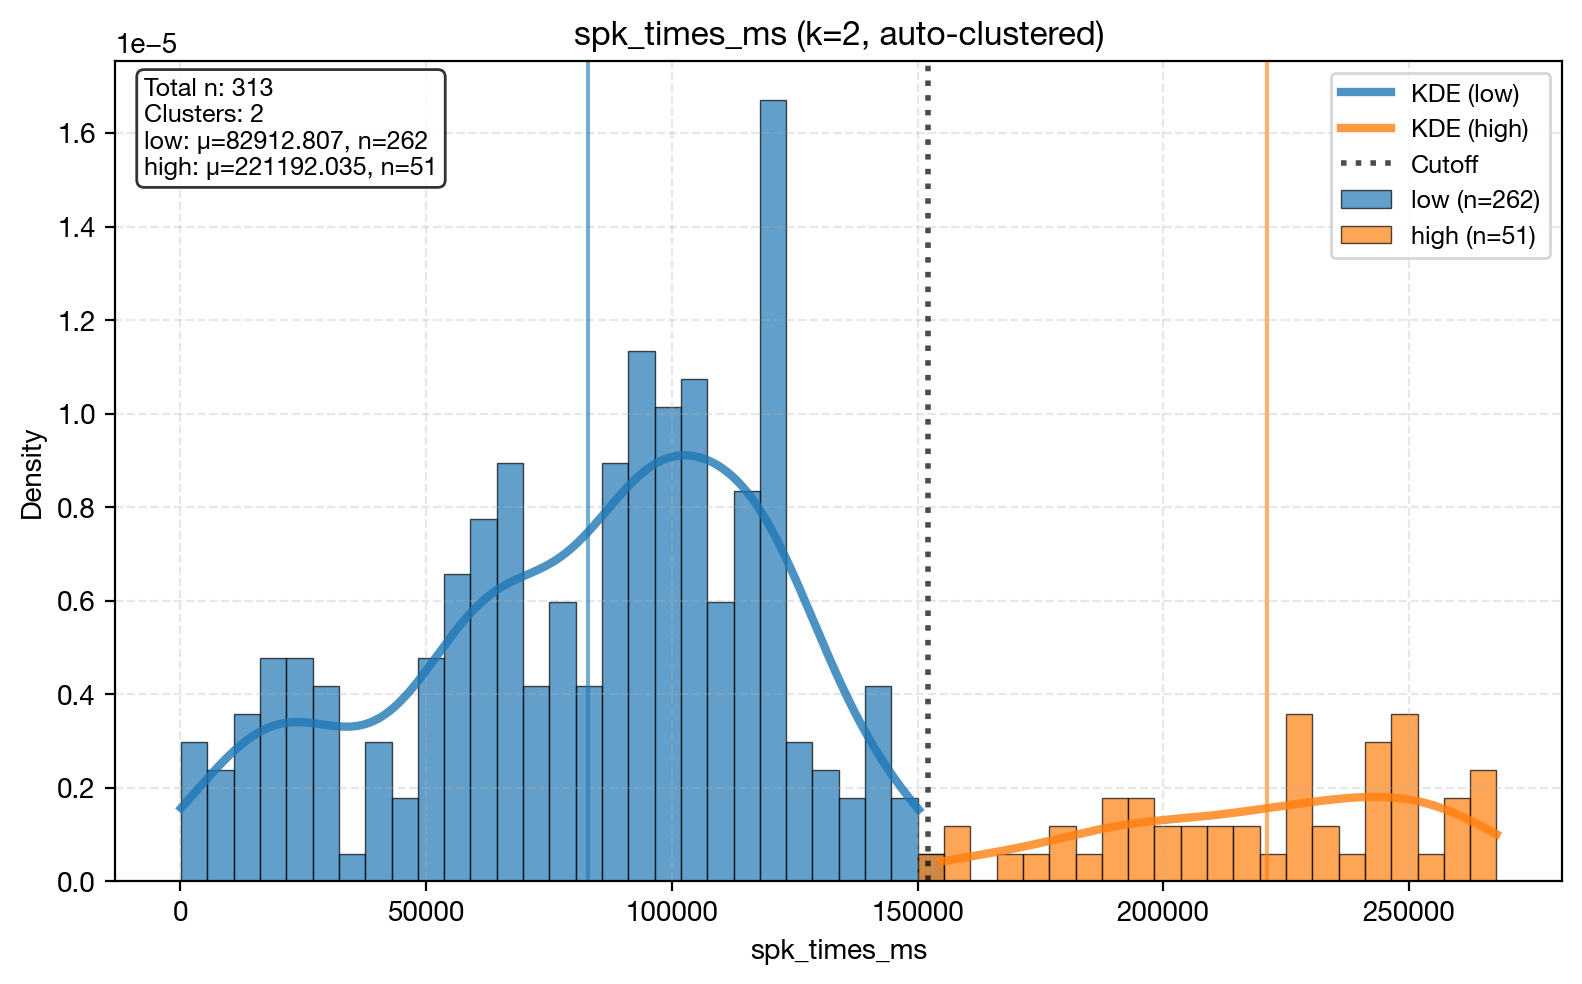

spk_id: Skipped - k_suggest = 1
  Saved: c39_cluster_df.pkl


In [19]:
cluster_pickle = os.path.join(SPE1_PICKLE_ROOT, 'cluster_pickles', f'c{cell_num}_cluster_df.pkl')

if FORCE_CLUSTER or not os.path.exists(cluster_pickle):
    # scan all numeric features and only cluster the ones that look multimodal
    df_features_clust, rep = cluster_multimodal_features(
        df_features.drop("spk_times_idx", axis = 1),
        max_k=2, ignore_features = "inflection_time",
        suffix="_cluster",
        plot_each=True,  # set True if you want a quick plot per clustered feature, 
        manual_thresholds={
        }
    )
    
    
    df_features_clust["r_squared_exp"]  = sp.r_squared_exp

    
    
    df_features_clust["r_squared_ramp"] = sp.r_squared_ramp

    
    
    with open(cluster_pickle, 'wb') as f:
        pickle.dump(df_features_clust, f)
    print(f"  Saved: {os.path.basename(cluster_pickle)}")
else:
    print(f"  [cache] {os.path.basename(cluster_pickle)}")
    with open(cluster_pickle, 'rb') as f:
        df_features_clust = pickle.load(f)
    if "r_squared_exp" not in df_features_clust.columns:
        df_features_clust["r_squared_exp"]  = sp.r_squared_exp
        df_features_clust["r_squared_ramp"] = sp.r_squared_ramp
        with open(cluster_pickle, "wb") as f:
            pickle.dump(df_features_clust, f)



===== CLUSTER REPORT: spk_times_ms_cluster =====
Found 2 clusters: ['high', 'low']

→ Determining cluster colors and labels...
  Using existing cluster labels: ['high', 'low']
  Groups: ('low', 'high')
  Group names: ('Low', 'High')

→ 1. Plotting spike waveforms by cluster


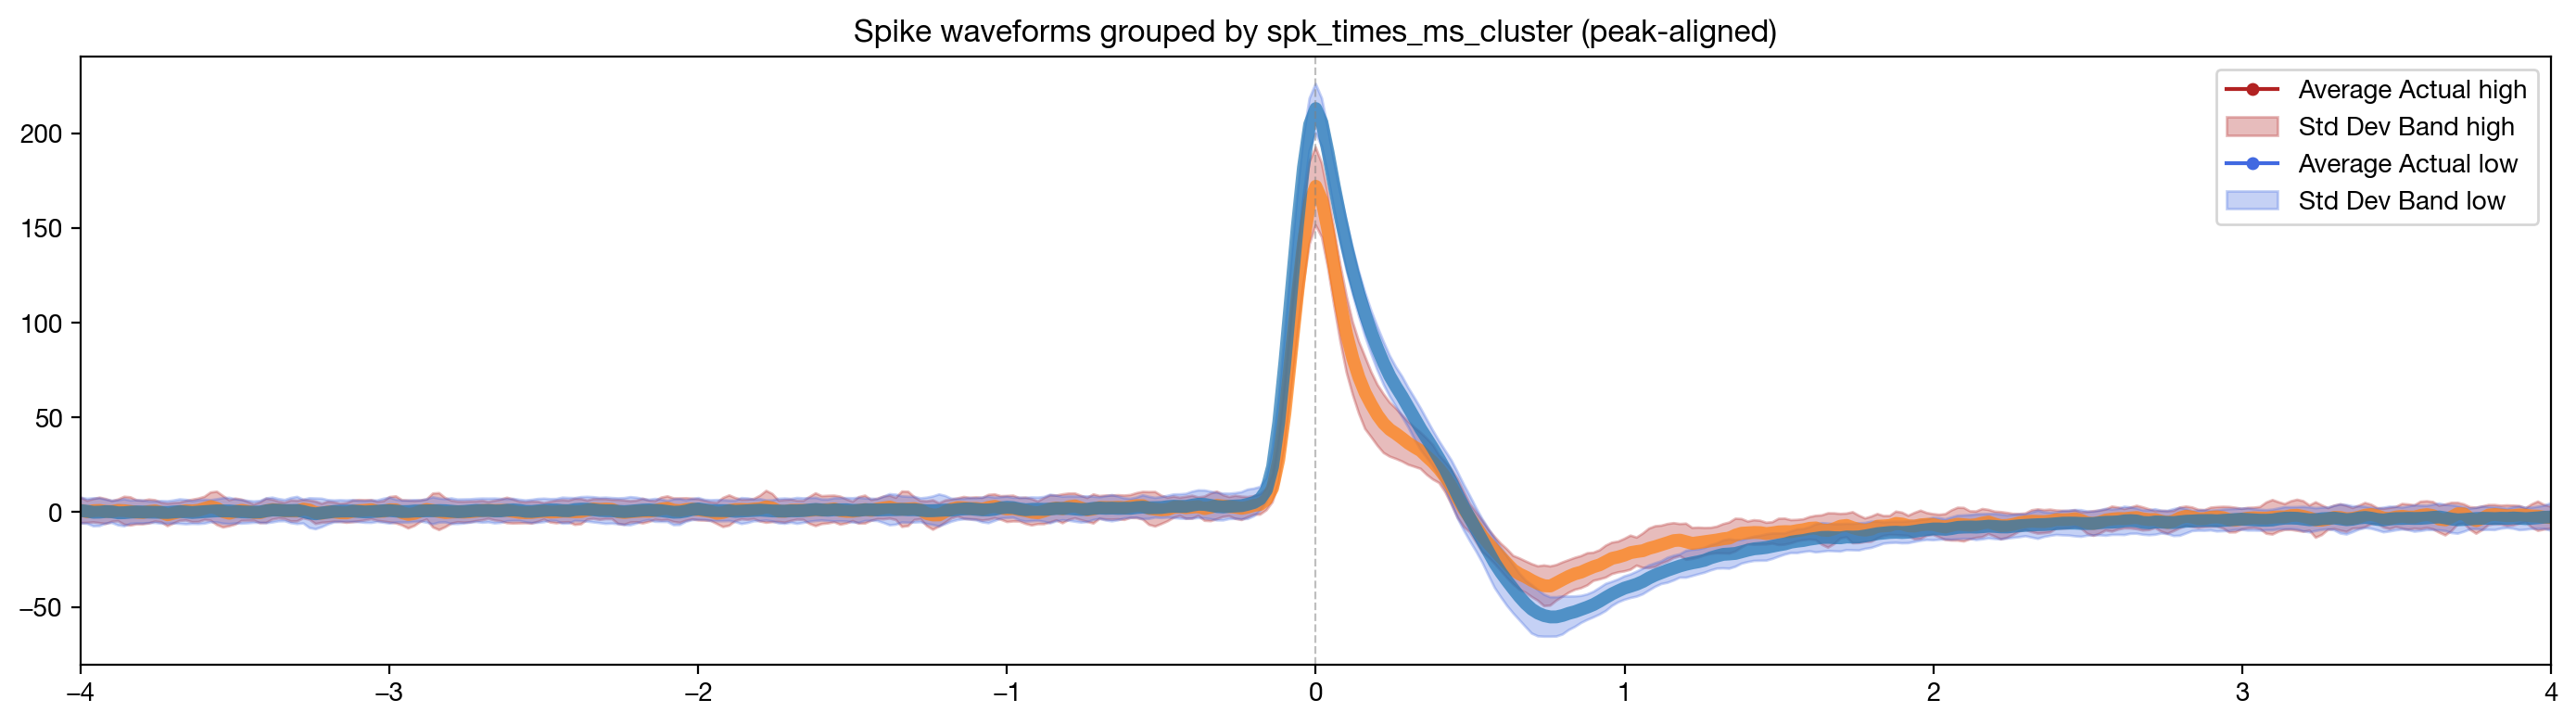


→ 1.5 Average waveforms with visual RMSE


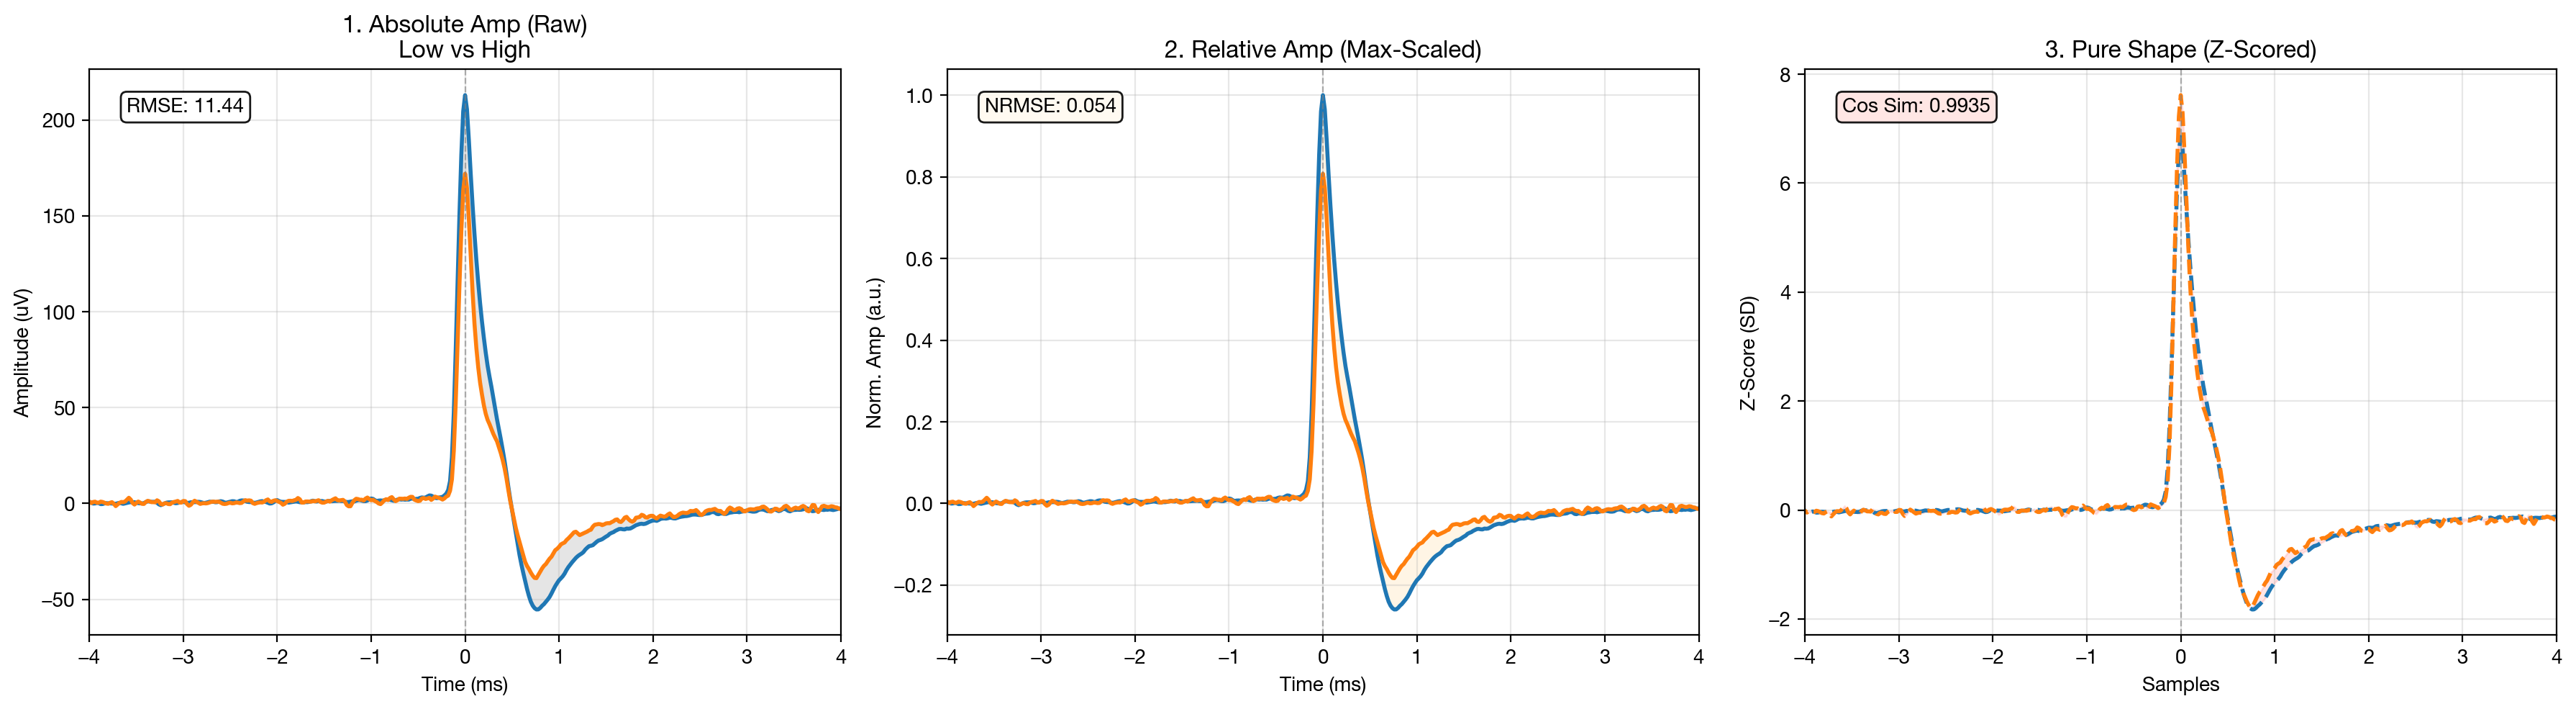


→ 2. Plotting cluster proportions over time


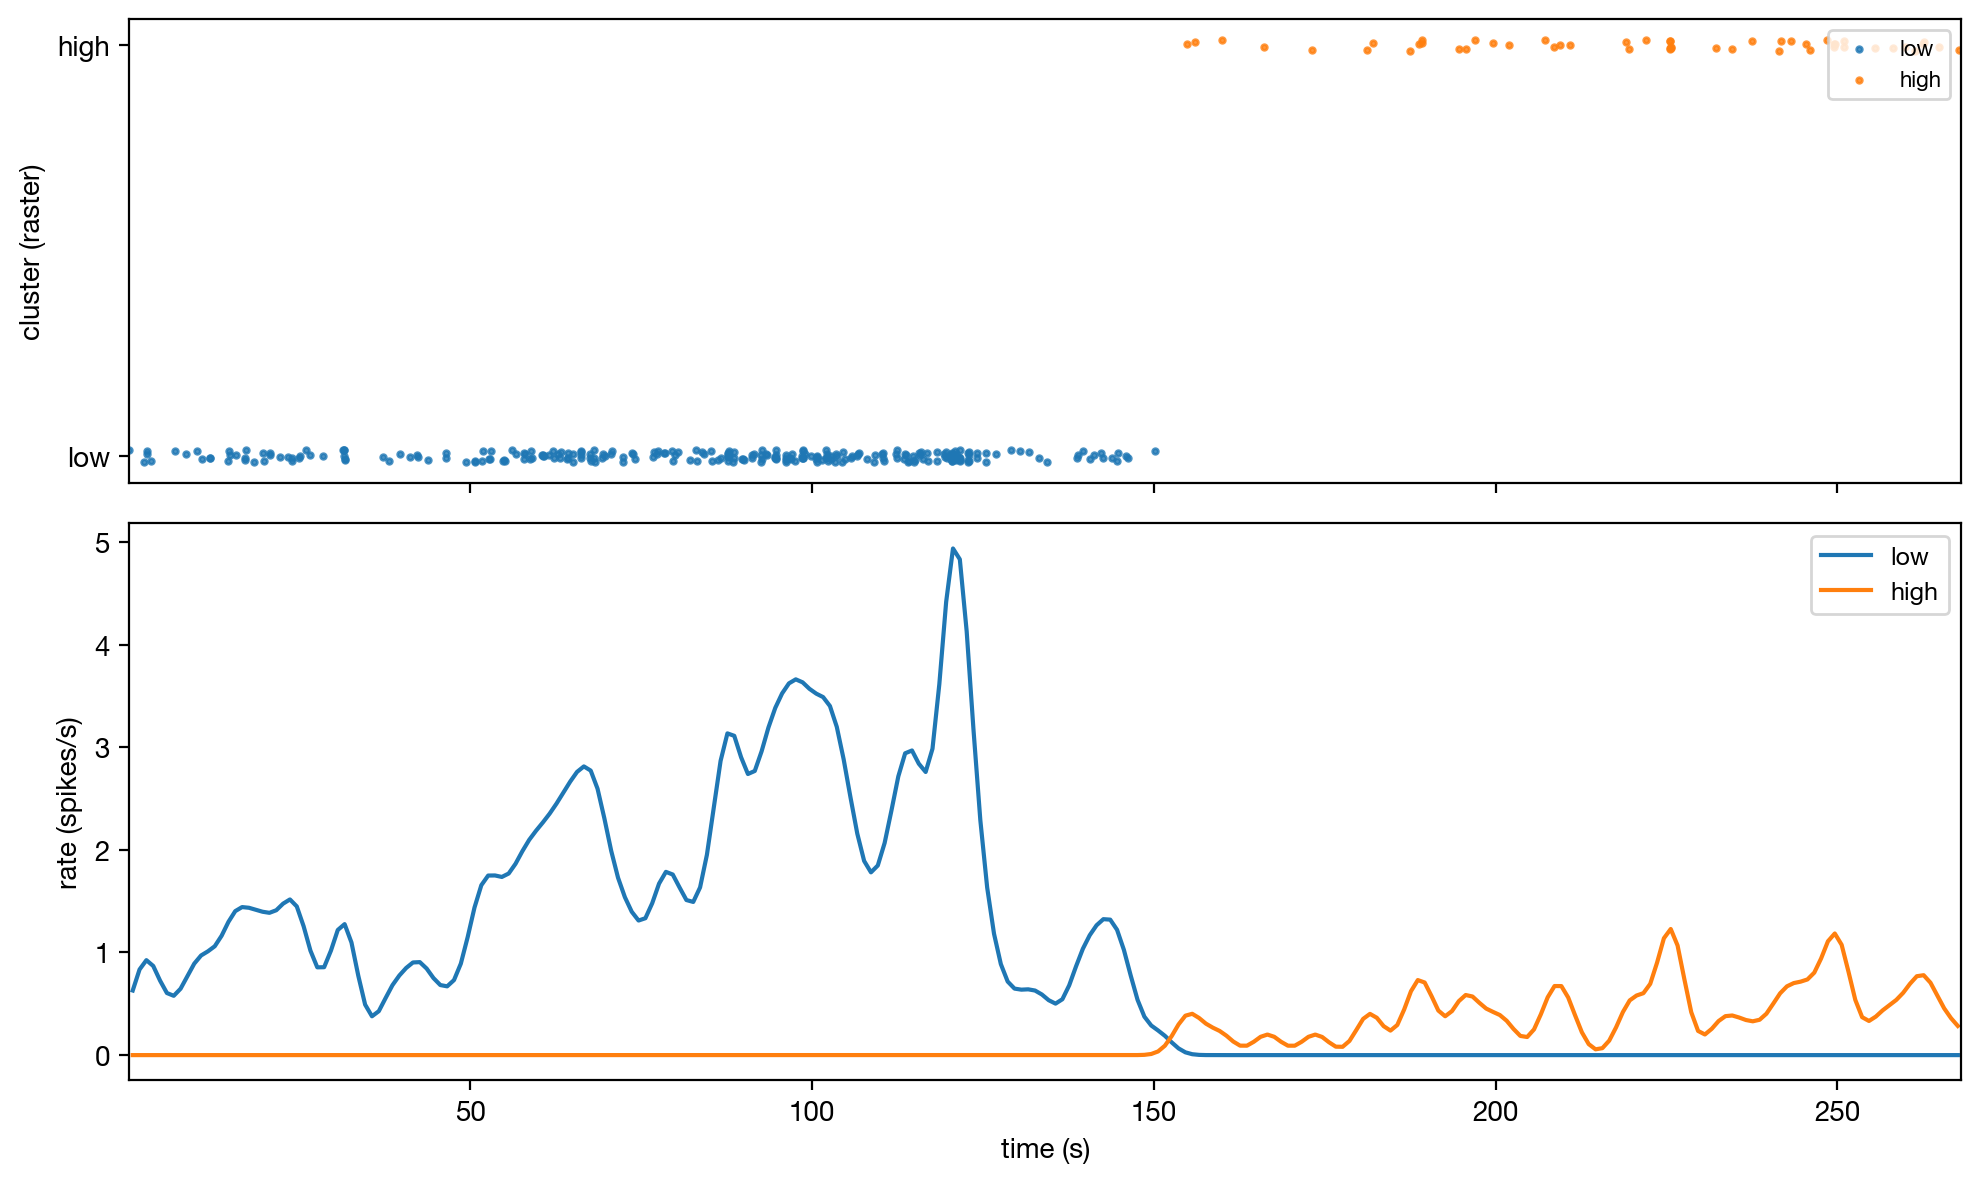


→ 3. Computing cluster transition matrix


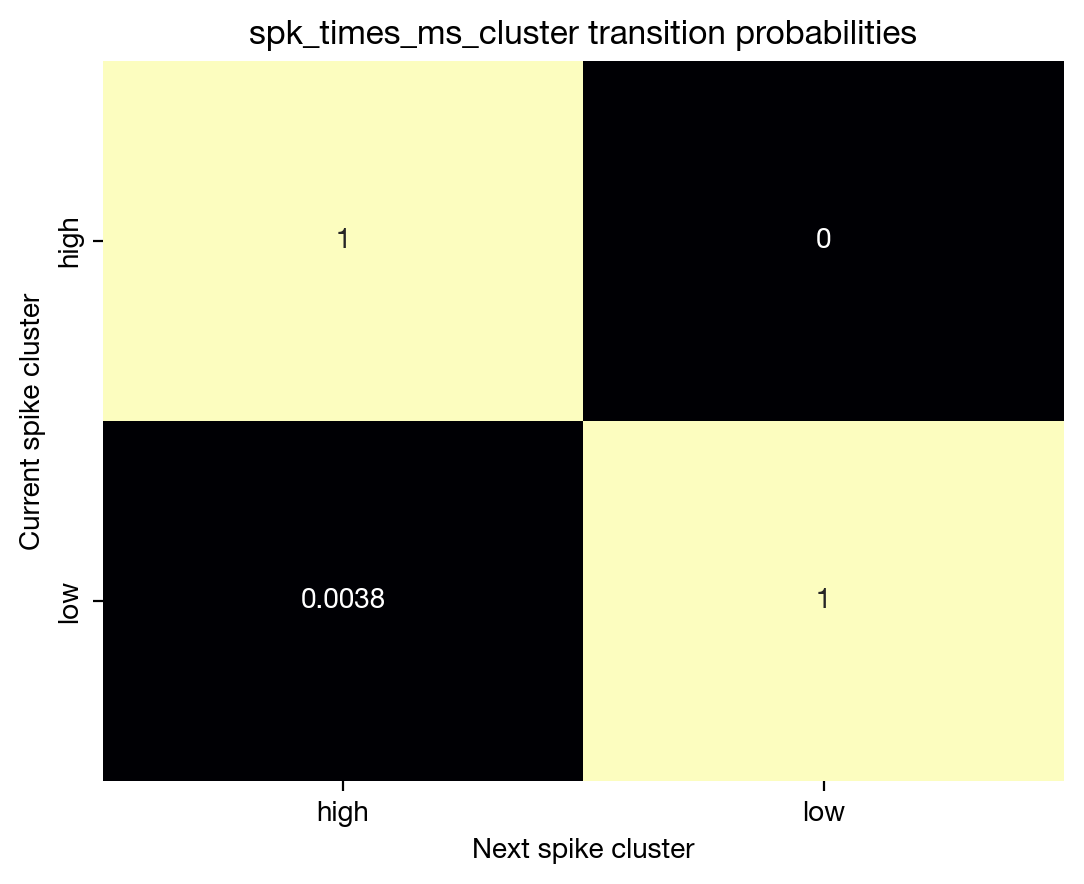


→ 4. Visualizing feature distributions by cluster


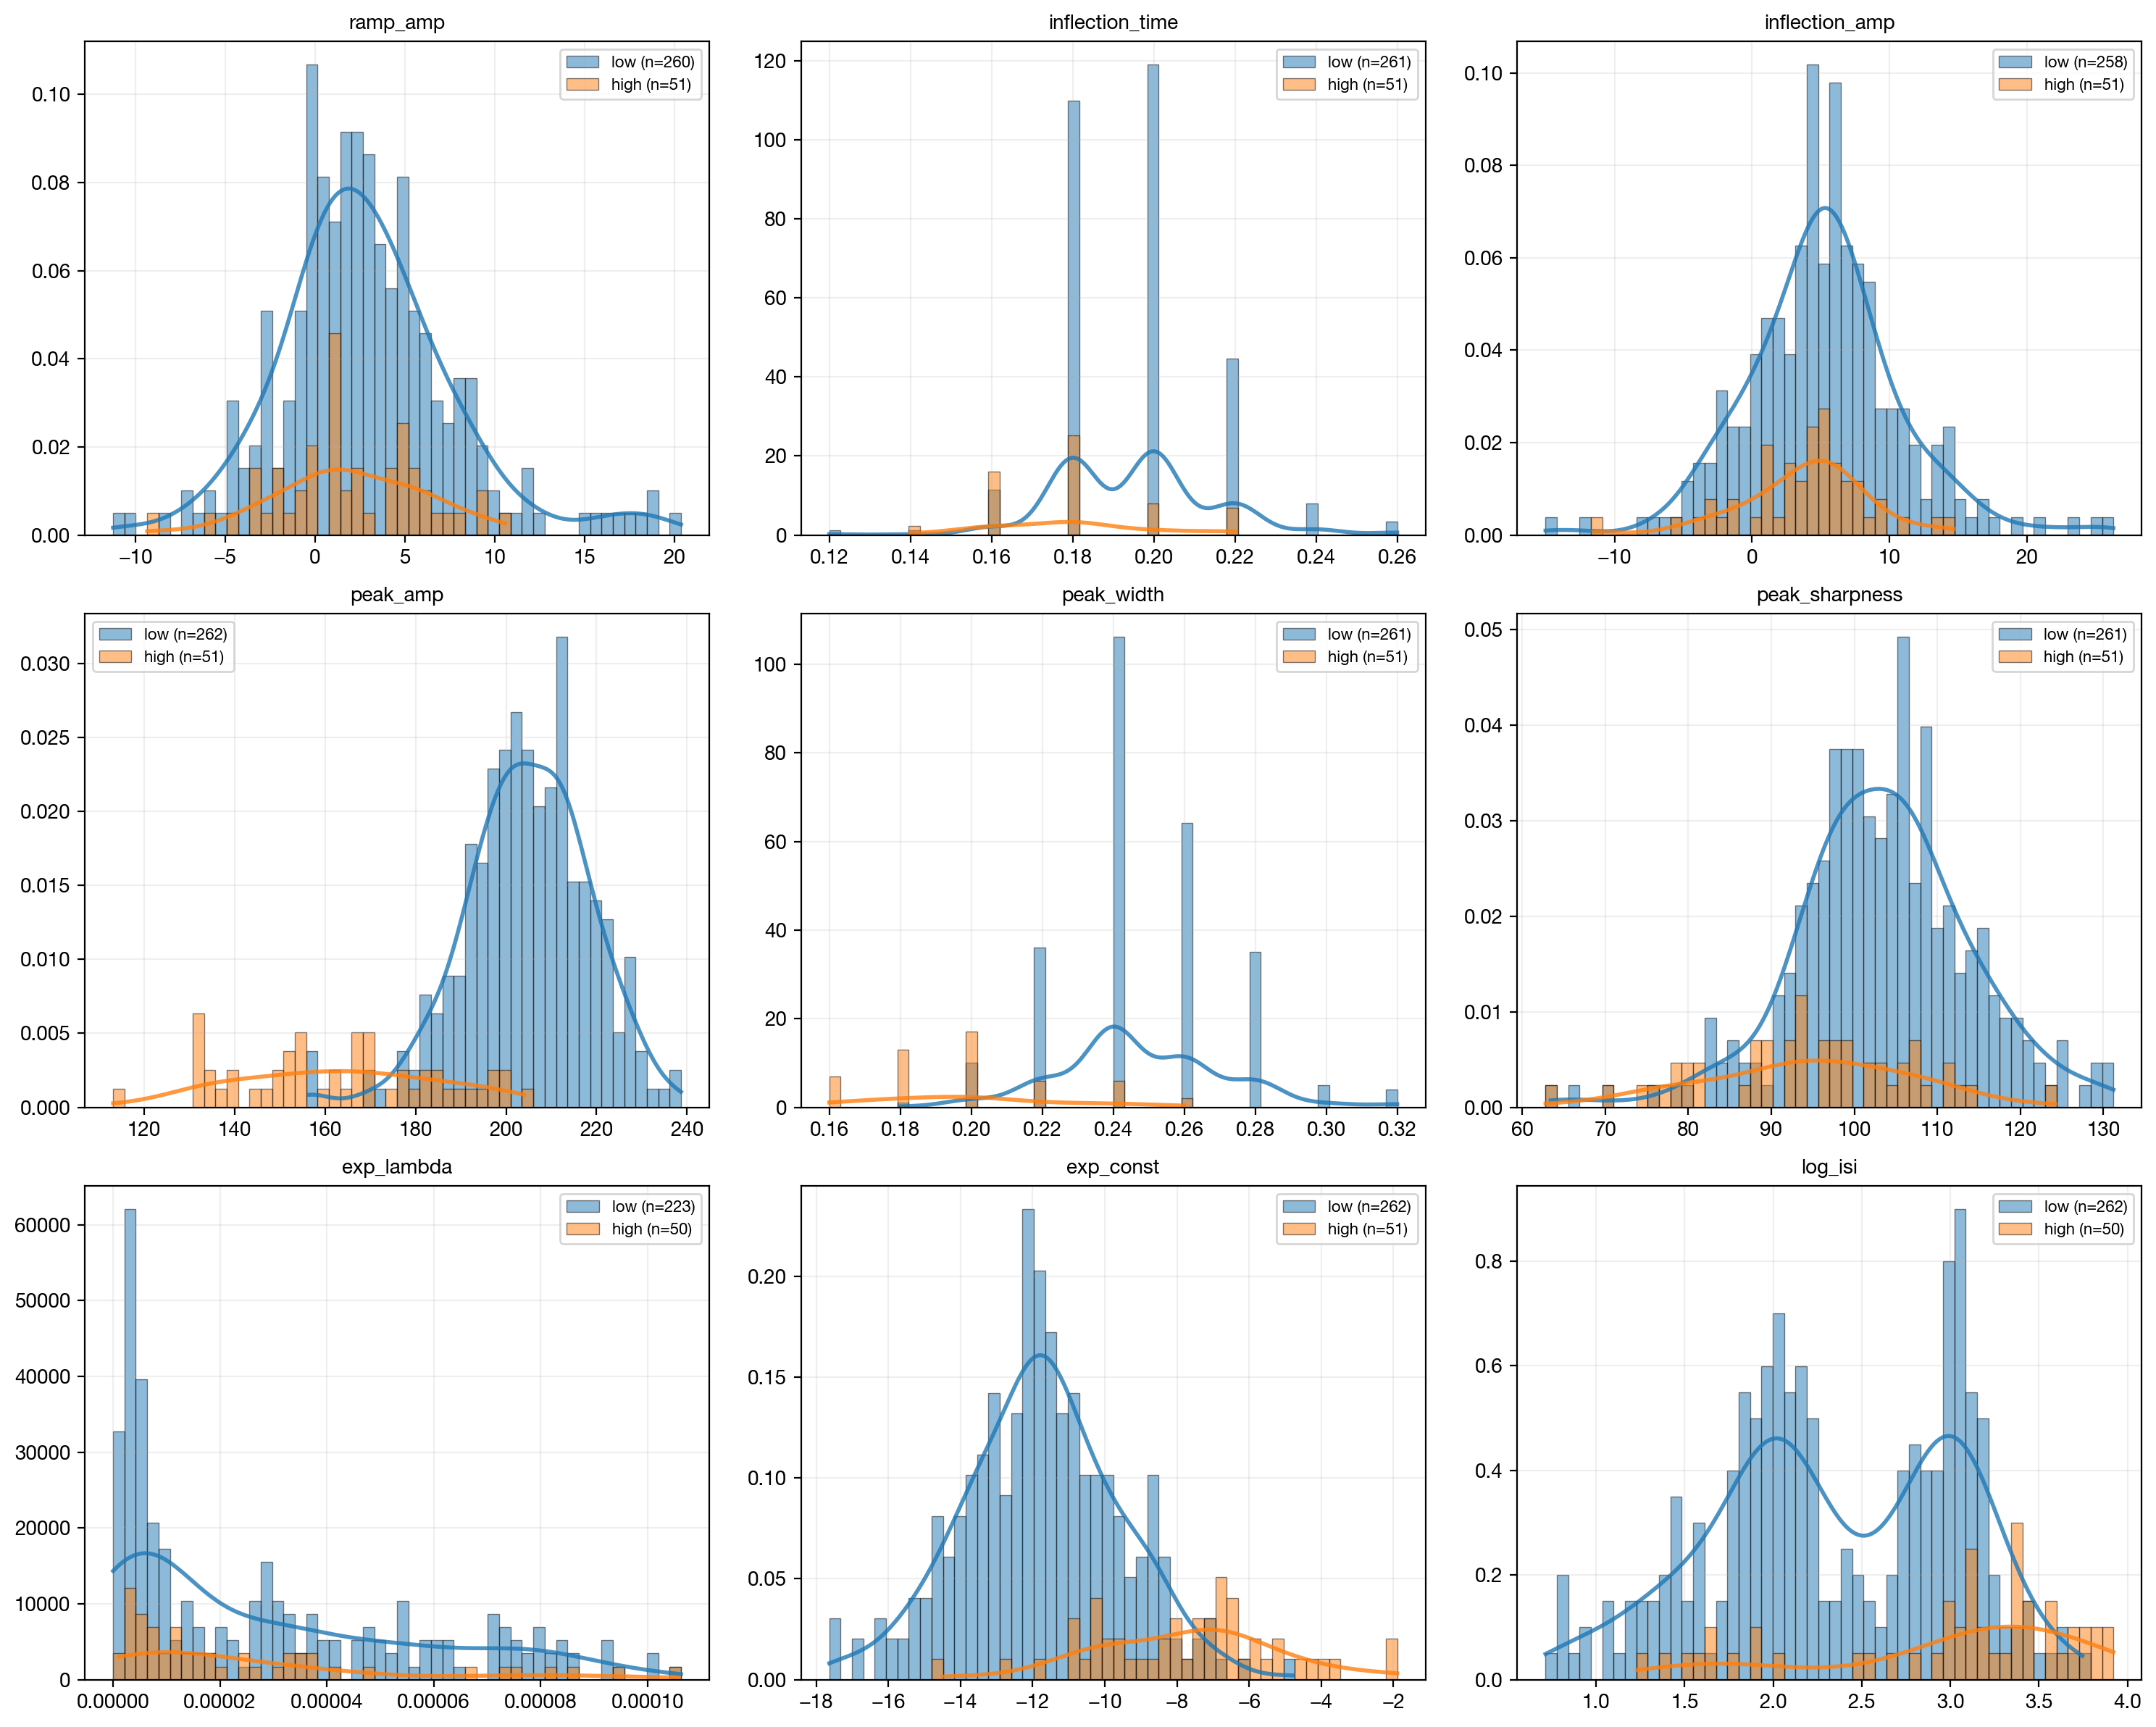


→ 5. Statistical analysis for: spk_times_ms
----------------------------------------

Test: Mann-Whitney U (nonparametric)
Number of groups: 2
P-value: 0.000000
Significance: ***
η² effect size: 0.672
Interpretation: Very Large


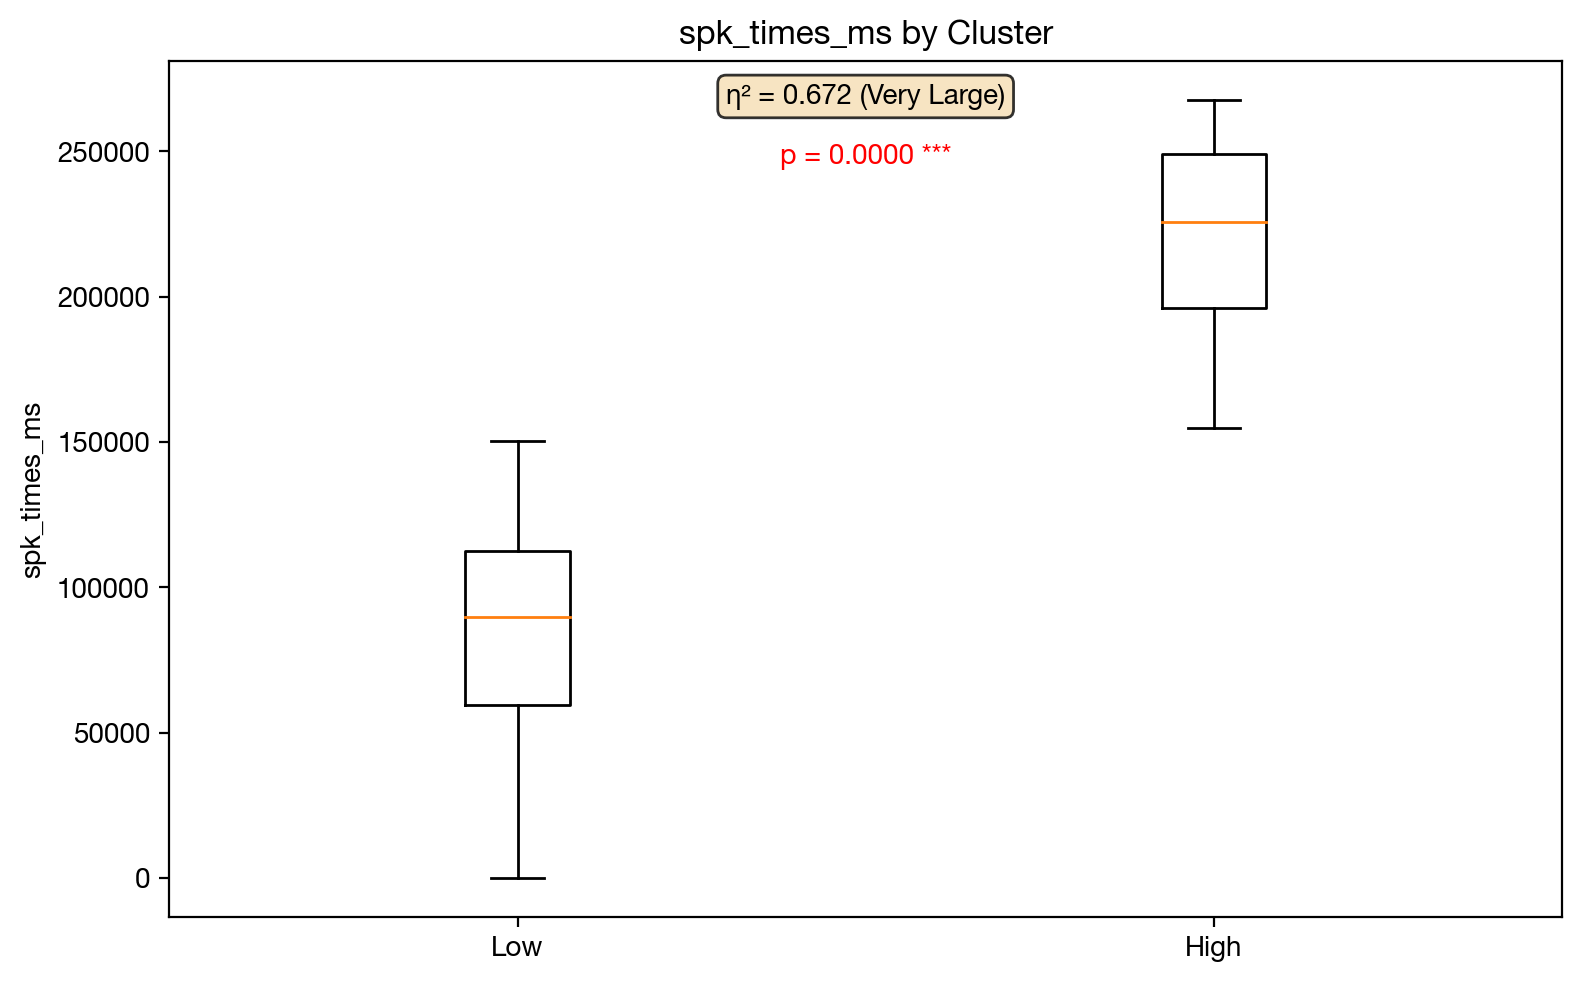


===== REPORT COMPLETE =====



In [20]:
all_reports = []

# Filter columns first to ensure the index is continuous
cluster_cols = [c for c in df_features_clust.columns if c.endswith("_cluster")]

for i, col in enumerate(cluster_cols):
    # Pass 'i' as the cluster_group_id
    row_df = plot_full_cluster_report(df_features_clust, sp, col, cluster_group_id=i)
    all_reports.append(row_df)

# Final Master DataFrame
master_report_df = pd.concat(all_reports, ignore_index=True)

In [21]:
# Save cluster quality report for population-level comparison analysis
report_pickle = os.path.join(SPE1_PICKLE_ROOT, 'cluster_pickles', f'c{cell_num}_cluster_report.pkl')
with open(report_pickle, 'wb') as f:
    pickle.dump(master_report_df, f)


In [22]:
# Compute and save peak-aligned average waveforms for each cluster group.
# Saved to a lightweight pickle used by the population comparison notebook.
wf_pickle = os.path.join(SPE1_PICKLE_ROOT, 'cluster_pickles', f'c{cell_num}_cluster_waveforms.pkl')
if FORCE_CLUSTER or not os.path.exists(wf_pickle):
    cluster_cols = [c for c in df_features_clust.columns if c.endswith('_cluster')]
    wf_data = compute_cluster_waveforms(sp, df_features_clust, cluster_cols)
    with open(wf_pickle, 'wb') as f:
        pickle.dump(wf_data, f)
    print(f"  Saved: {os.path.basename(wf_pickle)}")
else:
    print(f"  [cache] {os.path.basename(wf_pickle)}")


  Saved: c39_cluster_waveforms.pkl
